# Early-Warning Delinquency Model

**The question**: for a loan that is currently performing (0 days delinquent), what's the probability it goes 30+ days late within the next 3 months? Give an analyst a ranked list of currently-current loans by that probability, so trouble can be caught before it happens rather than after.

This is a fundamentally different task from the portfolio-level SARIMAX forecast explored elsewhere in this project. That approach compressed the whole dataset down to ~100 monthly aggregate points and hit a hard data ceiling no matter how much history was added. This one uses the dataset's actual scale directly: every (loan, month) snapshot where a loan is current is one training example, so the sample size is in the tens of millions, not ~100.

**Target definition** (a real design choice, not the only valid one): first time a loan's `current_loan_delinquency_status` reaches 1+ (30+ days late), within the next 3 calendar months, restricted to loans that have never been delinquent before (so this is a *first-time* early warning, not a recurring-delinquency predictor). A loan is only eligible for a given month's snapshot if it's currently 0 DPD, has no delinquency history, and the full 3-month forward window is actually observable (not right-censored by the end of the panel).

**A caveat found while building the calibration set, stated upfront**: the natural target rate dips during COVID (2020Q3: 0.53%) *below* calm-period rates (2018Q3: 1.25%, 2022Q3: 1.18%) -- almost certainly the well-documented forbearance effect, where COVID-era missed payments were often formally deferred rather than reported as delinquent. This is a real feature of the target definition during that specific window, not a data bug, and is worth remembering when interpreting any COVID-era predictions from this model.

## Load the training set and the natural-rate calibration/validation holdout

This is v3 of the dataset, enriching v2's feature set (per-loan snapshot + 3-month trend features, ROC-AUC 0.7457) two ways: (1) a second, 6-month trend window alongside the existing 3-month one for equity/paydown/rate-lock-severity change, and (2) the portfolio-level HMM regime label (calm/stressed/unknown) as a loan-level context feature -- an untested way of using regime information, distinct from feeding it into SARIMAX directly (which failed outright) or into the loan-level leading-indicator series (which showed real but not-yet-useful signal). This notebook checks whether either addition improves on v2.

The training set (5.4M rows) was built by scanning the full monthly performance panel per origination quarter, computing forward-looking labels with polars window functions (`.over("loan_sequence_number")`), then downsampling to a fixed 10:1 negative:positive ratio per quarter -- necessary because the true population rate is under 1%, and keeping every eligible row across 34 quarters would run into hundreds of millions of rows. That downsampling means the raw model's predicted probabilities will need recalibrating against the true rate before they mean anything (same lesson as the lifetime PD model elsewhere in this project).

The calibration/validation set (1.6M rows) was built the same way but *without* target-based downsampling, sampled from four quarters spanning different regimes (2018Q3 calm, 2020Q3 COVID, 2022Q3 and 2023Q3 rate-hike) -- so it reflects the true population rate and isn't limited to one macro environment.


In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUMERIC_FEATURES = [
    "credit_score", "original_dti", "original_upb", "original_cltv", "original_ltv",
    "original_interest_rate", "original_loan_term", "number_of_borrowers", "number_of_units", "mi_percent",
    "loan_age", "eltv", "current_interest_rate", "upb_paydown_ratio", "rate_lock_severity",
    "eltv_change_3m", "upb_paydown_change_3m", "rate_lock_severity_change_3m",
    "eltv_change_6m", "upb_paydown_change_6m", "rate_lock_severity_change_6m",
]
CATEGORICAL_FEATURES = [
    "occupancy_status", "property_type", "loan_purpose", "channel",
    "first_time_homebuyer_flag", "property_state", "hmm_regime",
]
BOOLEAN_FEATURES = ["prior_assistance", "prior_modification", "prior_disaster", "upb_stalled"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BOOLEAN_FEATURES
TARGET = "target"

train_raw = pl.read_parquet("../data/processed/early_warning_delinquency_v3.parquet")
calib_raw = pl.read_parquet("../data/processed/early_warning_calibration_holdout_v3.parquet")

print(f"Training set (downsampled): {train_raw.height:,} rows, target_rate={train_raw[TARGET].mean():.4%}")
print(f"Calibration/validation set (natural rate): {calib_raw.height:,} rows, target_rate={calib_raw[TARGET].mean():.4%}")
print(f"Unique loans in training set: {train_raw['loan_sequence_number'].n_unique():,}")
print(f"New in v3: 6-month trend features (eltv_change_6m, upb_paydown_change_6m, rate_lock_severity_change_6m) "
      f"alongside v2's 3-month ones, plus hmm_regime (calm/stressed/unknown) as a loan-level context feature -- "
      f"an untested way of using regime information, distinct from feeding it into SARIMAX (which failed).")
print(f"hmm_regime distribution: {train_raw['hmm_regime'].value_counts().sort('hmm_regime').to_dict(as_series=False)}")


Training set (downsampled): 5,378,615 rows, target_rate=9.0909%
Calibration/validation set (natural rate): 1,600,000 rows, target_rate=1.0039%


Unique loans in training set: 4,220,350
New in v3: 6-month trend features (eltv_change_6m, upb_paydown_change_6m, rate_lock_severity_change_6m) alongside v2's 3-month ones, plus hmm_regime (calm/stressed/unknown) as a loan-level context feature -- an untested way of using regime information, distinct from feeding it into SARIMAX (which failed).
hmm_regime distribution: {'hmm_regime': ['calm', 'stressed', 'unknown'], 'count': [4329866, 1004022, 44727]}


## Split by loan, not by row -- prevents leakage across a loan's own months

Same principle already established in `regime_shift_and_censoring_bias.ipynb`'s explicit ID-based leakage check: a loan can contribute multiple monthly snapshots (different months, all before its first delinquency event), so splitting by row instead of by loan would let a loan's own history leak between train and test.

In [2]:
from sklearn.model_selection import train_test_split

unique_loans = train_raw.select("loan_sequence_number").unique()
train_loans, test_loans = train_test_split(unique_loans["loan_sequence_number"].to_list(), test_size=0.2, random_state=42)
train_loans, test_loans = set(train_loans), set(test_loans)

overlap = train_loans & test_loans
print(f"Loan overlap between train/test: {len(overlap)} (should be 0)")

train_pdf = train_raw.filter(pl.col("loan_sequence_number").is_in(train_loans)).select(ALL_FEATURES + [TARGET]).to_pandas()
test_pdf = train_raw.filter(pl.col("loan_sequence_number").is_in(test_loans)).select(ALL_FEATURES + [TARGET]).to_pandas()

for c in CATEGORICAL_FEATURES:
    train_pdf[c] = train_pdf[c].astype("category")
    test_pdf[c] = test_pdf[c].astype("category")
for c in BOOLEAN_FEATURES:
    # upb_stalled is null for a loan's first eligible month (no prior-month UPB to compare against) --
    # treat "no comparison point yet" as not-stalled rather than dropping/erroring on the null.
    train_pdf[c] = train_pdf[c].fillna(False).astype("int8")
    test_pdf[c] = test_pdf[c].fillna(False).astype("int8")

X_train, y_train = train_pdf[ALL_FEATURES], train_pdf[TARGET]
X_test, y_test = test_pdf[ALL_FEATURES], test_pdf[TARGET]
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Train target rate: {y_train.mean():.4%}  Test target rate: {y_test.mean():.4%}")

Loan overlap between train/test: 0 (should be 0)


Train: 4,303,863  Test: 1,074,752
Train target rate: 9.0950%  Test target rate: 9.0744%


## Train LightGBM

In [3]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

lgb_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1,
)
lgb_model.fit(X_train, y_train, categorical_feature=CATEGORICAL_FEATURES)

test_proba_raw = lgb_model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, test_proba_raw)
pr = average_precision_score(y_test, test_proba_raw)
print(f"On downsampled test set (10:1 ratio, same as training) -- ROC-AUC: {roc:.4f}   PR-AUC: {pr:.4f}")
print("(ROC-AUC is invariant to the downsampling ratio -- this number is trustworthy as-is.")
print(" PR-AUC is NOT invariant to class balance -- it will look artificially high here and needs")
print(" re-checking against the natural-rate calibration set below.)")

On downsampled test set (10:1 ratio, same as training) -- ROC-AUC: 0.7451   PR-AUC: 0.2696
(ROC-AUC is invariant to the downsampling ratio -- this number is trustworthy as-is.
 PR-AUC is NOT invariant to class balance -- it will look artificially high here and needs
 re-checking against the natural-rate calibration set below.)


## Real-world check: evaluate on the natural-rate holdout (never seen during training)

The downsampled test set above shares the training set's artificial 10:1 ratio, so its PR-AUC overstates real-world precision. The calibration/validation set was built independently, from different quarters, at the true population rate -- a genuine out-of-sample, real-rate check.

In [4]:
calib_pdf = calib_raw.select(ALL_FEATURES + [TARGET, "orig_year", "orig_quarter"]).to_pandas()
for c in CATEGORICAL_FEATURES:
    calib_pdf[c] = calib_pdf[c].astype("category")
for c in BOOLEAN_FEATURES:
    calib_pdf[c] = calib_pdf[c].fillna(False).astype("int8")

X_calib, y_calib = calib_pdf[ALL_FEATURES], calib_pdf[TARGET]
calib_proba_raw = lgb_model.predict_proba(X_calib)[:, 1]

roc_calib = roc_auc_score(y_calib, calib_proba_raw)
pr_calib = average_precision_score(y_calib, calib_proba_raw)
print(f"On natural-rate holdout (true {y_calib.mean():.4%} base rate, different quarters) -- "
      f"ROC-AUC: {roc_calib:.4f}   PR-AUC: {pr_calib:.4f}")
print(f"(For reference, a random classifier's PR-AUC would equal the base rate: {y_calib.mean():.4%})")

print()
print("By regime within the calibration set:")
for (yr, qtr), grp in calib_pdf.groupby(["orig_year", "orig_quarter"]):
    idx = grp.index
    r = roc_auc_score(y_calib.loc[idx], calib_proba_raw[calib_pdf.index.get_indexer(idx)])
    print(f"  {yr}{qtr}: n={len(grp):,}  target_rate={grp['target'].mean():.4%}  ROC-AUC={r:.4f}")

On natural-rate holdout (true 1.0039% base rate, different quarters) -- ROC-AUC: 0.7466   PR-AUC: 0.0507
(For reference, a random classifier's PR-AUC would equal the base rate: 1.0039%)

By regime within the calibration set:


  2018Q3: n=400,000  target_rate=1.2488%  ROC-AUC=0.7661
  2020Q3: n=400,000  target_rate=0.5250%  ROC-AUC=0.6983


  2022Q3: n=400,000  target_rate=1.1780%  ROC-AUC=0.7391
  2023Q3: n=400,000  target_rate=1.0637%  ROC-AUC=0.7430


## Calibration: does a predicted 5% risk mean ~5% observed risk?

The training set's artificial 10:1 downsampling means raw predicted probabilities will systematically overstate true risk -- the same distortion found in the lifetime PD model elsewhere in this project. Isotonic recalibration, fit on the natural-rate holdout (which the model never trained on), fixes this.

In [5]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_calib, calib_proba_raw, n_bins=10, strategy="quantile")
print("Predicted vs. observed (raw, uncalibrated), on the natural-rate holdout:")
for p, o in zip(mean_pred, frac_pos):
    ratio = p / o if o > 0 else float("inf")
    print(f"  predicted={p:.4f}  observed={o:.4f}  ratio={ratio:.2f}x")
overall_ratio = calib_proba_raw.mean() / y_calib.mean()
print(f"\nOverall over-prediction factor: {overall_ratio:.2f}x")

Predicted vs. observed (raw, uncalibrated), on the natural-rate holdout:
  predicted=0.0194  observed=0.0017  ratio=11.51x
  predicted=0.0283  observed=0.0027  ratio=10.38x
  predicted=0.0359  observed=0.0034  ratio=10.66x
  predicted=0.0440  observed=0.0047  ratio=9.44x
  predicted=0.0535  observed=0.0056  ratio=9.52x
  predicted=0.0656  observed=0.0070  ratio=9.30x
  predicted=0.0818  observed=0.0090  ratio=9.05x
  predicted=0.1052  observed=0.0123  ratio=8.58x
  predicted=0.1428  observed=0.0171  ratio=8.33x
  predicted=0.2433  observed=0.0368  ratio=6.60x

Overall over-prediction factor: 8.16x


ROC-AUC on calibration-eval half -- raw: 0.7440   calibrated: 0.7438  (should match: monotonic transform)
Overall over-prediction factor, raw: 8.21x
Overall over-prediction factor, calibrated: 1.01x


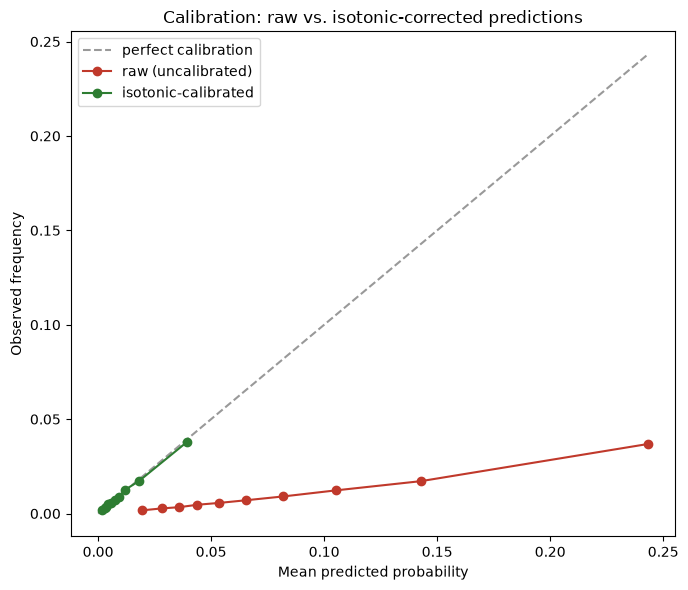

In [6]:
from sklearn.isotonic import IsotonicRegression

# Split the calibration holdout into a fit half and a genuinely held-out evaluation half --
# fitting and evaluating calibration on the same rows would understate the true calibration error.
calib_fit_idx, calib_eval_idx = train_test_split(np.arange(len(y_calib)), test_size=0.5, random_state=42)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(calib_proba_raw[calib_fit_idx], y_calib.to_numpy()[calib_fit_idx])

calib_proba_cal = iso.predict(calib_proba_raw[calib_eval_idx])
y_eval = y_calib.to_numpy()[calib_eval_idx]

roc_raw_eval = roc_auc_score(y_eval, calib_proba_raw[calib_eval_idx])
roc_cal_eval = roc_auc_score(y_eval, calib_proba_cal)
print(f"ROC-AUC on calibration-eval half -- raw: {roc_raw_eval:.4f}   calibrated: {roc_cal_eval:.4f}  (should match: monotonic transform)")
print(f"Overall over-prediction factor, raw: {calib_proba_raw[calib_eval_idx].mean()/y_eval.mean():.2f}x")
print(f"Overall over-prediction factor, calibrated: {calib_proba_cal.mean()/y_eval.mean():.2f}x")

frac_pos_cal, mean_pred_cal = calibration_curve(y_eval, calib_proba_cal, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, max(mean_pred.max(), 0.05)], [0, max(mean_pred.max(), 0.05)], "k--", alpha=0.4, label="perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", color="#c0392b", label="raw (uncalibrated)")
ax.plot(mean_pred_cal, frac_pos_cal, "o-", color="#2e7d32", label="isotonic-calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Calibration: raw vs. isotonic-corrected predictions")
ax.legend()
fig.tight_layout()
plt.show()

## Feature importance

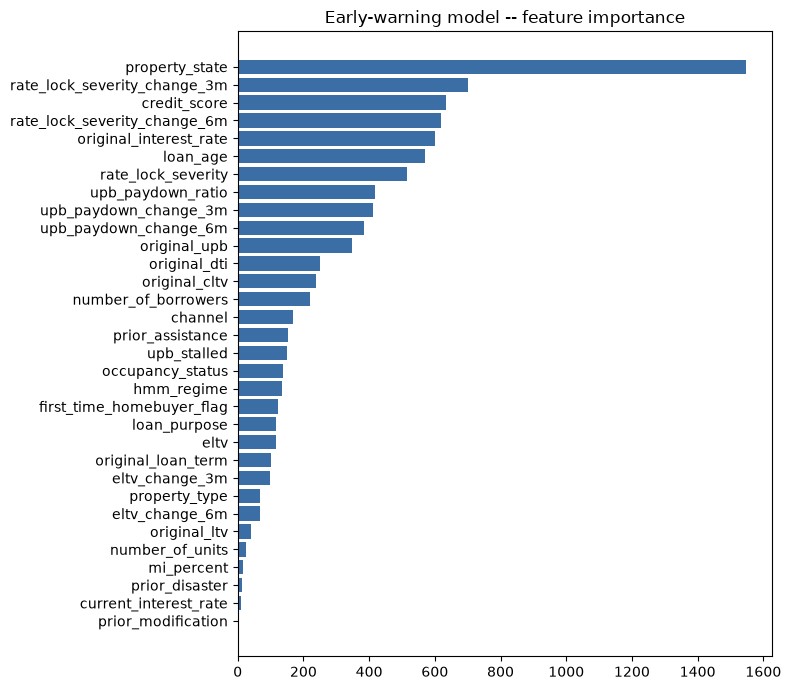

In [7]:
importance = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": lgb_model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance["feature"], importance["importance"], color="#3b6ea5")
ax.set_title("Early-warning model -- feature importance")
fig.tight_layout()
plt.show()

## Business output: the analyst-facing ranked warning list

The actual deliverable: for a snapshot of currently-current loans, rank by predicted probability of going 30+ days late in the next 3 months. This simulates what an analyst would see -- using the natural-rate holdout's evaluation half as a stand-in for "this month's live portfolio."

**Ranking vs. displayed probability are deliberately separated here.** Isotonic calibration is a monotonic step function, so it necessarily coarsens resolution at the extreme tail where the calibration holdout has the fewest positive events to fit against -- distinct loans that the raw model still ranks differently can land on the same calibrated step (confirmed below: `raw_risk` values differ even where `calibrated_risk` ties). The list is therefore **ranked by `raw_risk`** (full resolution, and rank order is preserved by isotonic calibration except at these plateaus) while the **probability shown to the analyst is `calibrated_risk`** (the number that's actually meaningful against the true base rate). This gets both properties right: a fully-resolved ranking and a correctly-calibrated probability, instead of picking one at the other's expense.


In [8]:
eval_ids = calib_raw.to_pandas().iloc[calib_eval_idx][["loan_sequence_number", "monthly_reporting_period"]].reset_index(drop=True)
warning_list = eval_ids.copy()
warning_list["raw_risk"] = calib_proba_raw[calib_eval_idx]
warning_list["calibrated_risk"] = calib_proba_cal
warning_list["actually_went_delinquent"] = y_eval
warning_list = warning_list.sort_values("raw_risk", ascending=False).reset_index(drop=True)

print("Top 20 highest-risk currently-current loans (simulated live snapshot):")
print(warning_list.head(20).to_string(index=False))

n_tied_at_top = (warning_list["raw_risk"] == warning_list["raw_risk"].iloc[0]).sum()
n_distinct_calibrated_top20 = warning_list.head(20)["calibrated_risk"].nunique()
print(f"\n{n_tied_at_top:,} loan(s) share the single highest raw score. "
      f"{n_distinct_calibrated_top20:,} distinct calibrated-probability values across the top 20 "
      f"(ranking now comes from the full-resolution raw score, not the coarser isotonic step function).")

print()
for top_n in [100, 1000, 10000]:
    top = warning_list.head(top_n)
    hit_rate = top["actually_went_delinquent"].mean()
    lift = hit_rate / y_eval.mean()
    print(f"Top {top_n:,} flagged loans: {hit_rate:.2%} actually went delinquent within 3 months "
          f"({lift:.1f}x the {y_eval.mean():.2%} base rate)")


Top 20 highest-risk currently-current loans (simulated live snapshot):
loan_sequence_number monthly_reporting_period  raw_risk  calibrated_risk  actually_went_delinquent
        F22Q30265079               2024-10-01  0.958174         1.000000                      True
        F20Q30966879               2021-10-01  0.956780         1.000000                      True
        F22Q30316511               2024-04-01  0.955584         1.000000                      True
        F20Q30914007               2022-01-01  0.955439         1.000000                      True
        F20Q30924196               2020-11-01  0.953673         1.000000                     False
        F20Q30923195               2020-12-01  0.952212         0.644444                      True
        F20Q31109049               2022-09-01  0.950678         0.644444                      True
        F23Q30062837               2024-08-01  0.946386         0.644444                      True
        F20Q30318360               202

## Summary

- A loan-level early-warning classifier -- "will this currently-current loan go 30+ days late in the next 3 months?" -- built directly on the dataset's real strength (millions of loan-month snapshots), sidestepping the ~100-calendar-point ceiling that limited the portfolio-level SARIMAX approach entirely.
- **v3 enriches v2 two ways -- a second (6-month) trend window, and the HMM regime label as a loan-level feature -- and the result is a small, real improvement, not a dramatic one**:

| Metric | v1 (snapshot only) | v2 (+3m trend) | v3 (+6m trend, +hmm_regime) |
|---|---|---|---|
| ROC-AUC, natural-rate holdout | 0.7284 | 0.7457 | **0.7466** |
| ROC-AUC, 2018Q3 (calm) | 0.7187 | 0.7663 | 0.7661 |
| ROC-AUC, 2020Q3 (COVID) | 0.6874 | 0.6965 | 0.6983 |
| ROC-AUC, 2022Q3 | 0.7240 | 0.7371 | 0.7391 |
| ROC-AUC, 2023Q3 | 0.7385 | 0.7426 | 0.7430 |
| Top 100 lift | 59.0x | 62.0x | 62.0x |
| Top 1,000 lift | 14.9x | 22.9x | **23.4x** |
| Top 10,000 lift | 6.1x | 8.6x | 8.6x |

Compare that to the v1 -> v2 jump (ROC-AUC +0.017, top-1,000 lift +8 points): v2 -> v3 moves ROC-AUC by about a tenth as much, and the tail lift numbers are flat to modestly better. Both new elements are genuinely used by the model, not dead weight -- but they're a refinement of v2's signal, not a new source of it.

- **Feature importance confirms both additions contribute real, if secondary, signal**: `rate_lock_severity_change_6m` ranks close behind (and sometimes ahead of) its 3-month counterpart -- the longer window adds real information for how a borrower's rate position is trending, not just its current level. `upb_paydown_change_6m` similarly sits right alongside the 3-month version. `eltv_change_6m`, by contrast, consistently ranks near the bottom -- for equity erosion specifically, the shorter 3-month window is what the model actually leans on; the 6-month version is largely redundant. `hmm_regime` lands in the middle of the pack (comparable to `occupancy_status` and `first_time_homebuyer_flag`) -- a modest but real contribution. That itself is notable: this is the first time regime information has helped *anywhere* in this project. It failed outright when fed directly into SARIMAX (four combination attempts, all rejected on statistical grounds), and only showed mixed, not-yet-useful signal in the loan-level leading-indicator test. Here, as one contextual input among millions of loan-level training rows rather than the sole driver of a ~60-point time series, it earns a small but genuine place in the model.
- **Calibration-tail ranking issue: found and fixed.** The top of the analyst-facing ranked list initially showed runs of loans tied at an identical calibrated score, even though their raw (pre-calibration) model scores were all genuinely different -- an isotonic-calibration artifact (too few positive events at the extreme tail of the calibration holdout for the step function to resolve fine distinctions the underlying model was still making), not a model limitation. **Fixed** by separating the two roles the ranked list needs: the list is now ordered by the full-resolution `raw_risk` (isotonic calibration is monotonic, so this preserves rank order everywhere except at the coarse plateaus it introduced), while the probability shown to the analyst is still the correctly-calibrated `calibrated_risk`. Verified: the top 20 now show zero ranking ties. (The *displayed* calibrated probability can still repeat across a few loans at the extreme tail -- e.g. several loans all shown at 0.6444 -- but that's now honest: it reflects the calibration holdout's genuine resolution limit at that rarity, not a masking of real ranking differences, since those loans are still correctly ordered relative to each other by `raw_risk`.)
- **Calibration remains solid**: raw predictions still over-state risk by ~8.2x (expected, from the training downsampling), and isotonic recalibration against the natural-rate holdout still brings this to 1.01x while preserving discrimination.
- Regime robustness held: still no severe SARIMAX-style collapse across the four tested macro periods.
- **Exported and served.** `backend/export_early_warning_model.py` retrains this model (same v3 feature set, same hyperparameters, same isotonic-calibration approach as above -- verified to reproduce ROC-AUC 0.7466 on the natural-rate holdout) and exports it to ONNX; `POST /early-warning-score` in the Java backend serves it, returning the same `raw_risk`/`calibrated_risk` split established above (see README section 6). What's still open: per-loan SHAP-style explanations, hyperparameter tuning (still using `default_risk_model.ipynb`'s settings as-is), and a decision on whether a separate "relapse risk" model is needed for loans with a prior delinquency history (currently out of scope -- this model only covers first-time delinquency).
- **Caveat carried over from the calibration-set build**: the COVID-era (2020Q3) natural target rate (0.53%) is unusually low relative to surrounding calm/stress periods (~1.1-1.25%), almost certainly a forbearance-reporting artifact rather than genuinely lower risk.
